In [93]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PREFIX = "inertial-6286.188861:"

buff = []
with open("CB_ARW.csv", "r") as file:
    data = False
    for line in file:
        
        if line == "DATA_START\n":
            data = True
            continue
        
        if data == True:
            line = line.rstrip()
            values = line.split(",")
            buff.append(values)

header = [b.lstrip(PREFIX) for b in buff[0]]

buff = np.array(buff)

df = pd.DataFrame(data=buff[1:], columns=header)

# Conversion de tipo de datos de df (string a numerico)
for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# print(df)

fs = 100
dt = 1 / fs

In [94]:
def mean(df, col): 
    return np.mean(pd.to_numeric(df[col], errors="coerce"))

def variance(df, col):    
    return np.var(pd.to_numeric(df[col], errors="coerce"))

def standard_deviation(df, col):  
    return np.std(pd.to_numeric(df[col], errors="coerce"))
    
# for column in df.columns[1:]:
#     print(column)
#     mean(df=df, col=column)
#     variance(df=df, col=column)
#     standard_deviation(df=df, col=column)

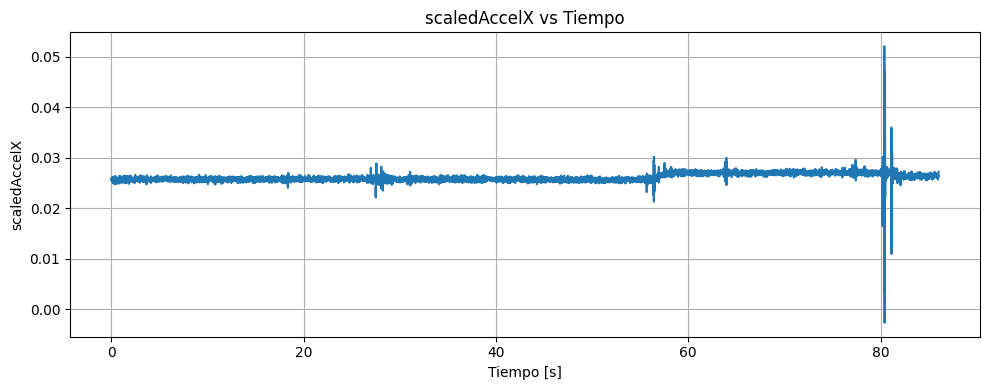

scaledAccelX  u: 0.026089552689001635  o2: 8.911465795915039e-07  o: 0.0009440056035805634


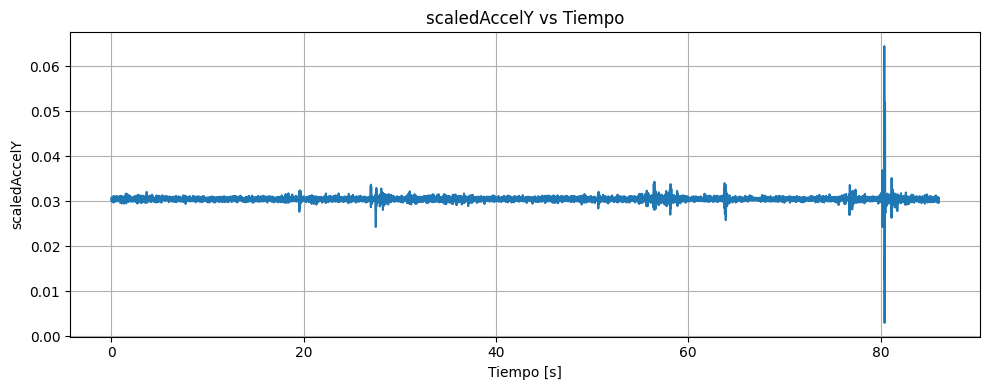

scaledAccelY  u: 0.030465976023837615  o2: 6.878948621045187e-07  o: 0.0008293942742173463


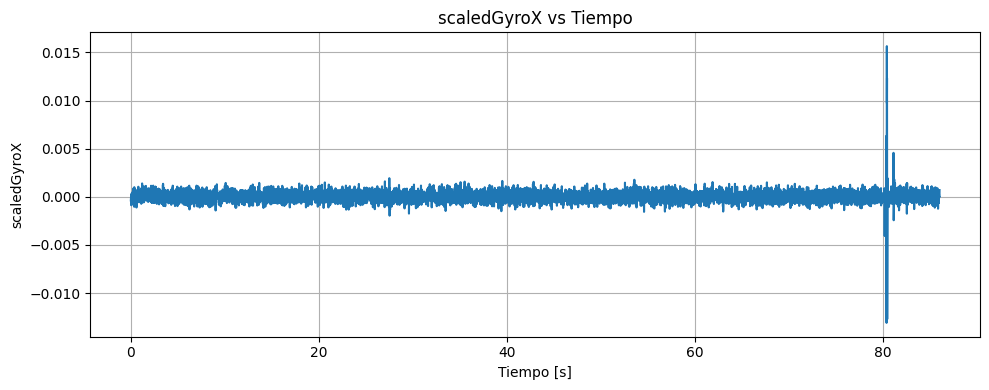

scaledGyroX  u: 4.477527819828205e-05  o2: 3.567157626296475e-07  o: 0.0005972568648660705


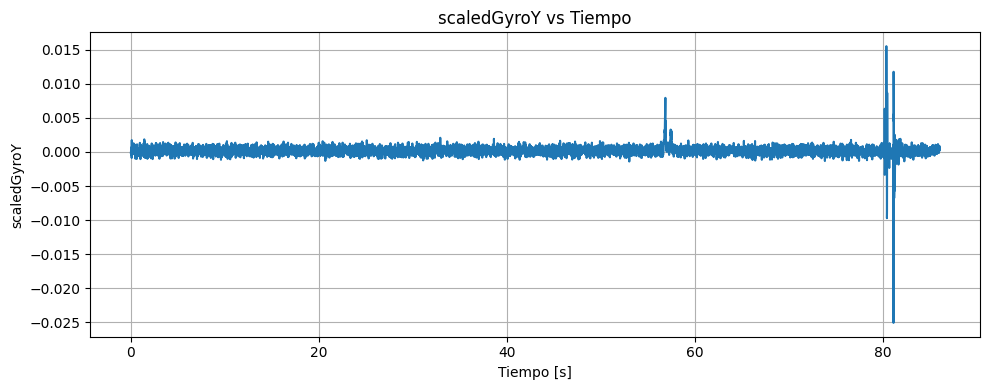

scaledGyroY  u: 0.00018673683159263282  o2: 5.068063698265775e-07  o: 0.0007119033430365231


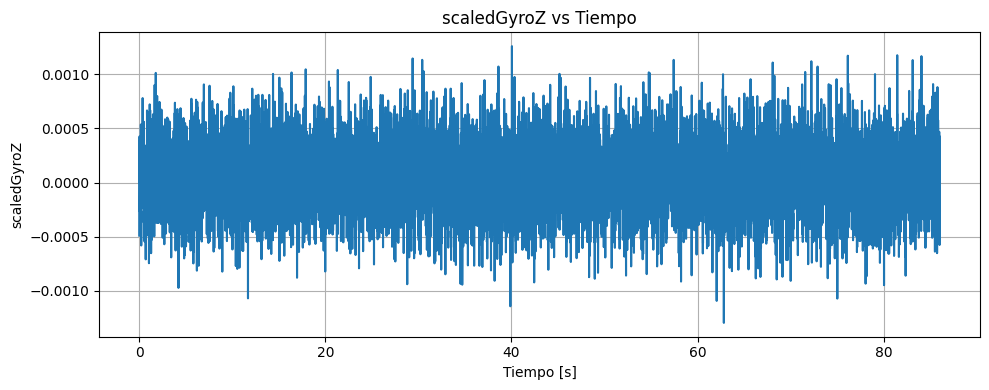

scaledGyroZ  u: 5.958619644443901e-05  o2: 1.1042411869531022e-07  o: 0.0003323012469060419


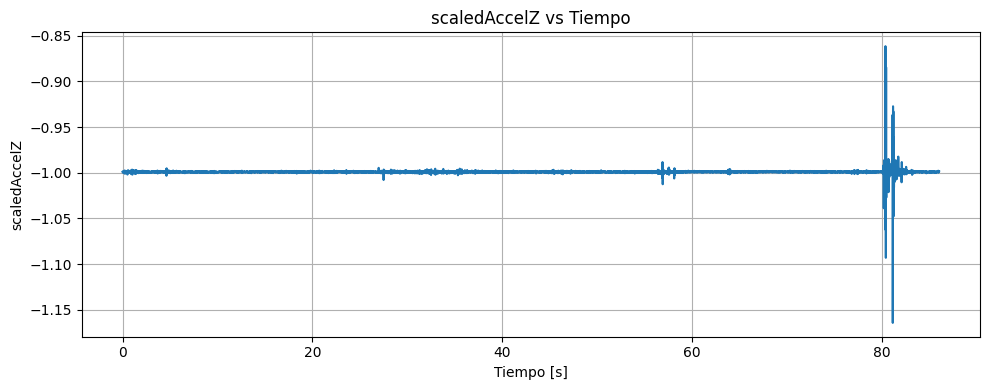

scaledAccelZ  u: -0.9991111311920848  o2: 1.3117254244953299e-05  o: 0.003621775013022385
{'scaledAccelX': np.float64(0.026089552689001635), 'scaledAccelY': np.float64(0.030465976023837615), 'scaledGyroX': np.float64(4.477527819828205e-05), 'scaledGyroY': np.float64(0.00018673683159263282), 'scaledGyroZ': np.float64(5.958619644443901e-05), 'scaledAccelZ': np.float64(-0.9991111311920848)}


In [95]:
# sigma = 0.01 # desviación estandar

# rudio_gyro = np.random.normal(loc=0, scale=sigma, size=n)

# # plt.plot(np.arange(n) * dt, rudio_gyro)
# # plt.xlabel("Tiempo [s]")
# # plt.ylabel("Ruido del giroscopio [deg/s]")
# # plt.title("Ruido blanco en velocidad angular")
# # plt.grid()
# # plt.show()

# print(df.columns[3])
biases = {}

def plot_data_vs_time(df, col):
    df = df.copy()

    # Convertir Time a numérico
    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

    # Eliminar filas donde Time no pudo convertirse
    # df = df.dropna(subset=["Time"])

    # Tiempo relativo en segundos
    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # for col in df.columns:
    #     if col == "Time":
    #         continue

    # Convertir también la columna actual a numérico por seguridad
    y = pd.to_numeric(df[col], errors="coerce")

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col)
    plt.title(f"{col} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
        
# plot_data_vs_time(df=df, col="scaledAccelY")

for column in df.columns[1:]:
    plot_data_vs_time(df=df, col=column)
    print(column, " u:", mean(df,column), " o2:", variance(df,column)," o:", standard_deviation(df,column))
    biases[column] = mean(df,column)

print(biases)

# print(biases[df.columns[1]])

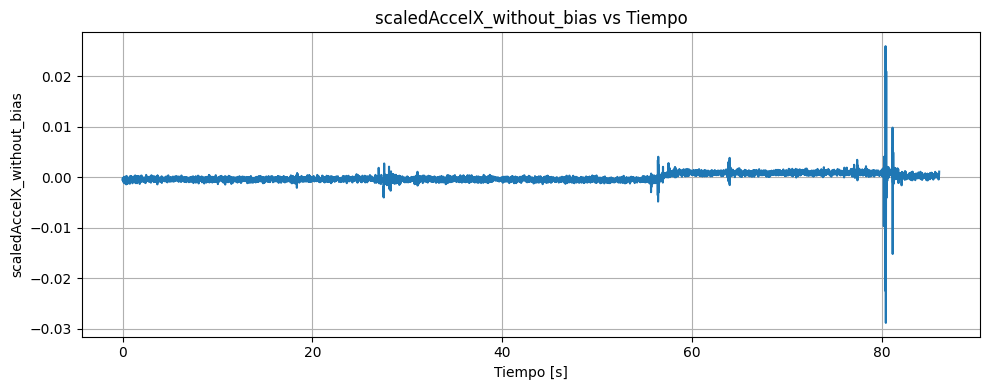

scaledAccelX_without_bias  u: 2.167547566961375e-18  o2: 8.911465795915039e-07  o: 0.0009440056035805634


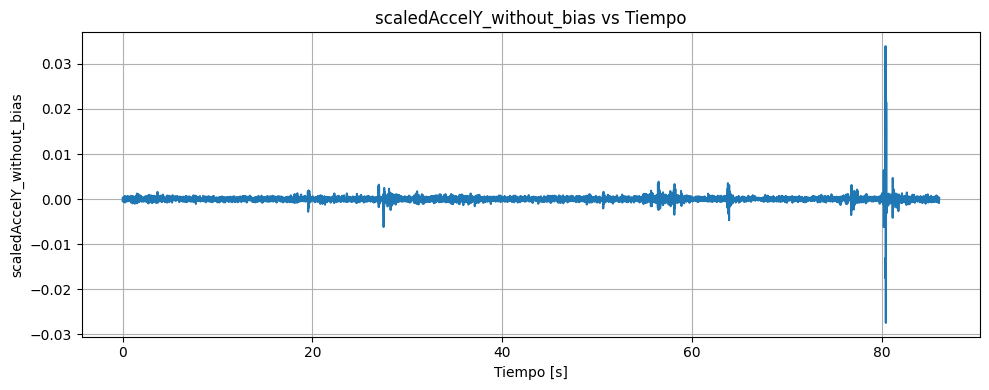

scaledAccelY_without_bias  u: -3.9544841028194125e-18  o2: 6.878948621045188e-07  o: 0.0008293942742173464


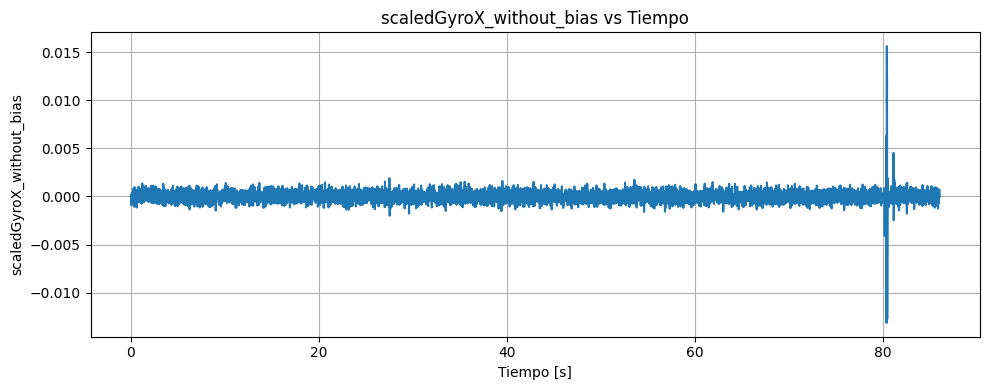

scaledGyroX_without_bias  u: -4.838275819110212e-21  o2: 3.567157626296475e-07  o: 0.0005972568648660705


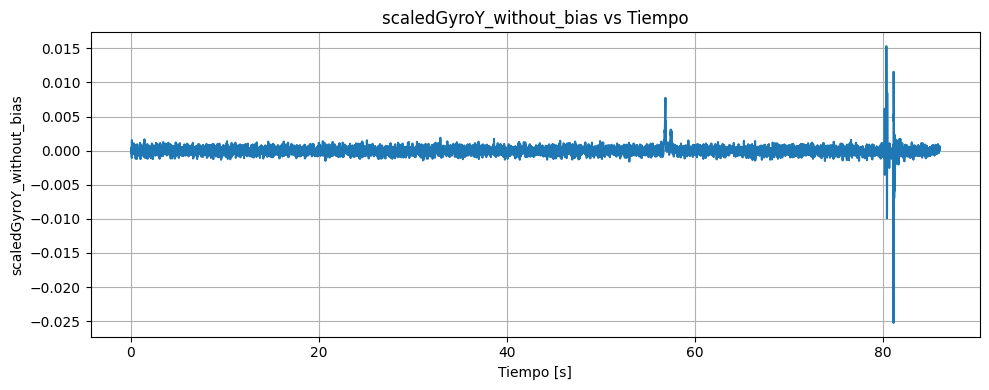

scaledGyroY_without_bias  u: -4.838275819110212e-21  o2: 5.068063698265775e-07  o: 0.0007119033430365231


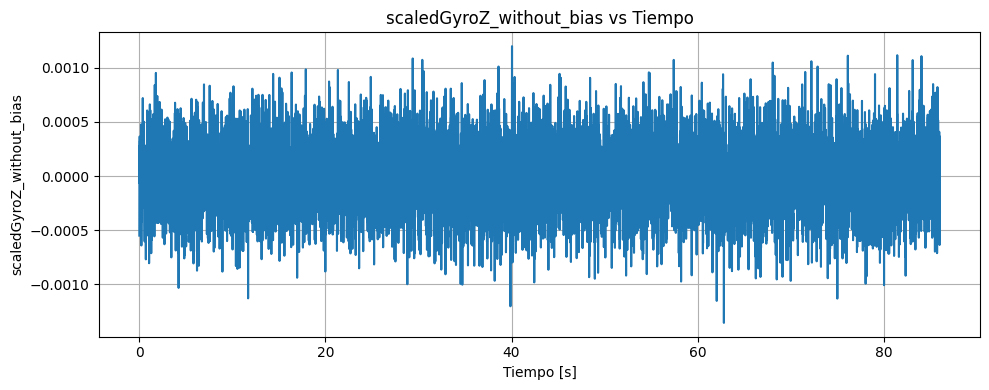

scaledGyroZ_without_bias  u: 1.209568954777553e-21  o2: 1.1042411869531022e-07  o: 0.0003323012469060419


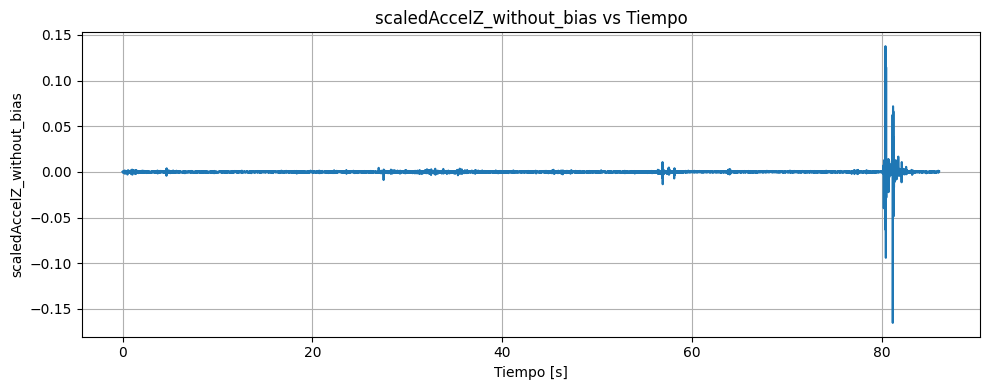

scaledAccelZ_without_bias  u: -3.7428901736636595e-17  o2: 1.31172542449533e-05  o: 0.0036217750130223855
Index(['Time', 'scaledAccelX', 'scaledAccelY', 'scaledGyroX', 'scaledGyroY',
       'scaledGyroZ', 'scaledAccelZ', 'scaledAccelX_without_bias',
       'scaledAccelY_without_bias', 'scaledGyroX_without_bias',
       'scaledGyroY_without_bias', 'scaledGyroZ_without_bias',
       'scaledAccelZ_without_bias'],
      dtype='str')
0.026089552689001635 8.911465795915039e-07 0.0009440056035805634
{'scaledAccelX': np.float64(0.0009440056035805634), 'scaledAccelY': np.float64(0.0008293942742173464), 'scaledGyroX': np.float64(0.0005972568648660705), 'scaledGyroY': np.float64(0.0007119033430365231), 'scaledGyroZ': np.float64(0.0003323012469060419), 'scaledAccelZ': np.float64(0.0036217750130223855)}


In [96]:
var = {}
std = {}

def data_without_bias(df, col_input, col_output):

    df[col_output] = df[col_input] - mean(df, col_input)

    # Tiempo relativo en segundos
    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # for col in df.columns:
    #     if col == "Time":
    #         continue

    # Convertir también la columna actual a numérico por seguridad
    y = pd.to_numeric(df[col_output], errors="coerce")

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col_output)
    plt.title(f"{col_output} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for column in df.columns[1:]:
    data_without_bias(df=df, col_input=column, col_output=column+"_without_bias")
    print(column+"_without_bias", " u:", mean(df,column+"_without_bias"), " o2:", variance(df,column+"_without_bias")," o:", standard_deviation(df,column+"_without_bias"))
    var[column] = variance(df,column+"_without_bias")
    std[column] = standard_deviation(df,column+"_without_bias")
    
print(df.columns[:])
print(biases[df.columns[1]], var[df.columns[1]] ,std[df.columns[1]])
print(std)

# for column in df.columns[1:]:
#     print(column, " u:", mean(df,column), " o2:", variance(df,column)," o:", standard_deviation(df,column))

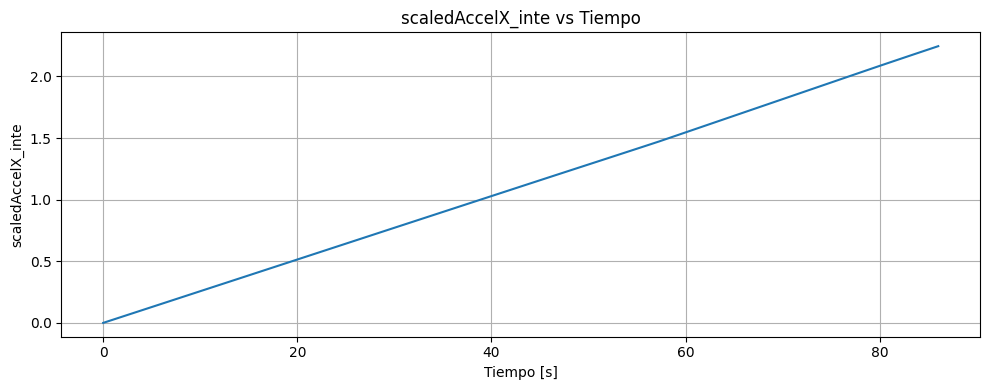

scaledAccelX_inte  u: 1.1119243253169997  o2: 0.41784275278026195  o: 0.6464075748165873


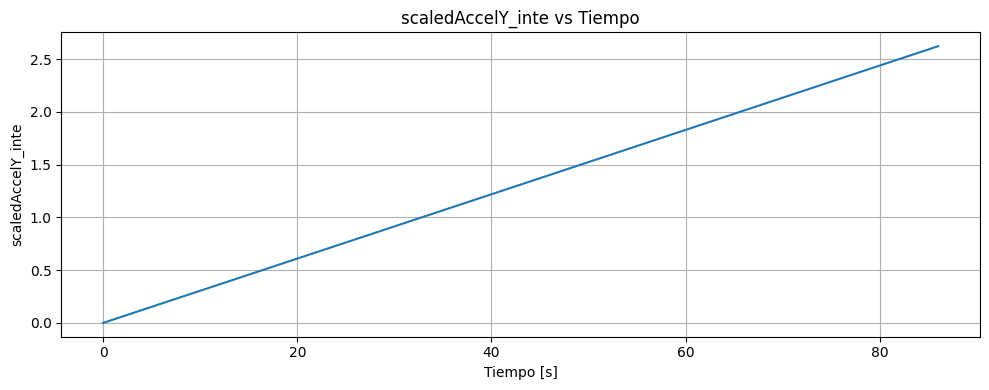

scaledAccelY_inte  u: 1.3107013717487213  o2: 0.572734563477593  o: 0.7567922855563427


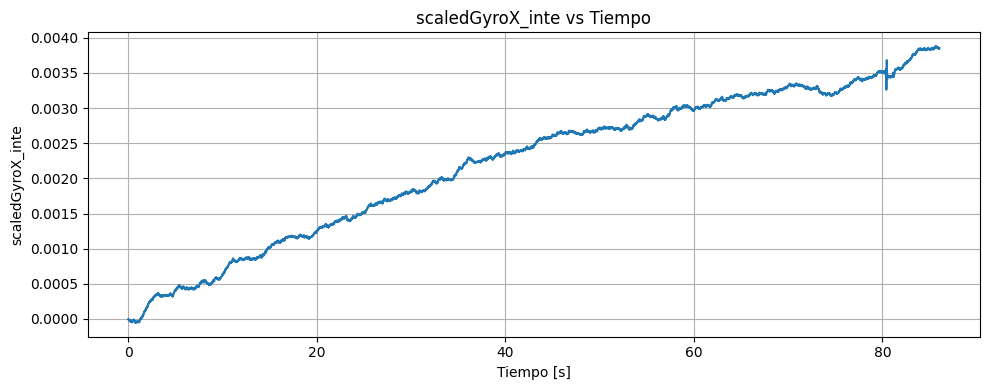

scaledGyroX_inte  u: 0.0022176262175000855  o2: 1.112931644225648e-06  o: 0.0010549557546293816


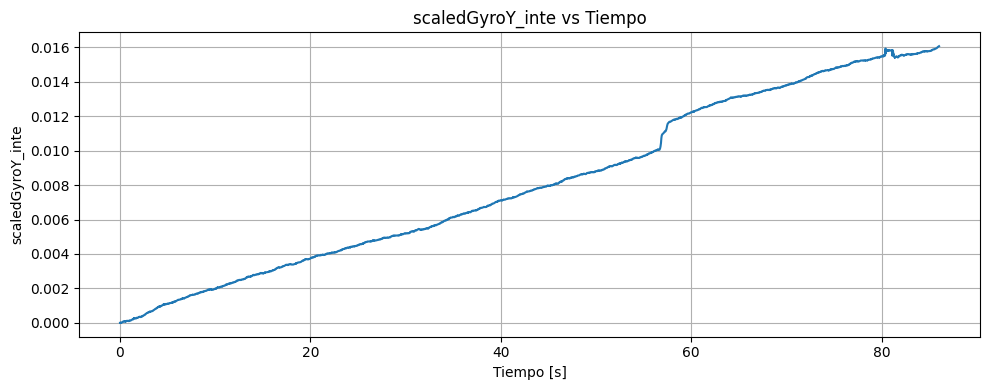

scaledGyroY_inte  u: 0.008128110822563617  o2: 2.3793984008212634e-05  o: 0.004877907749046986


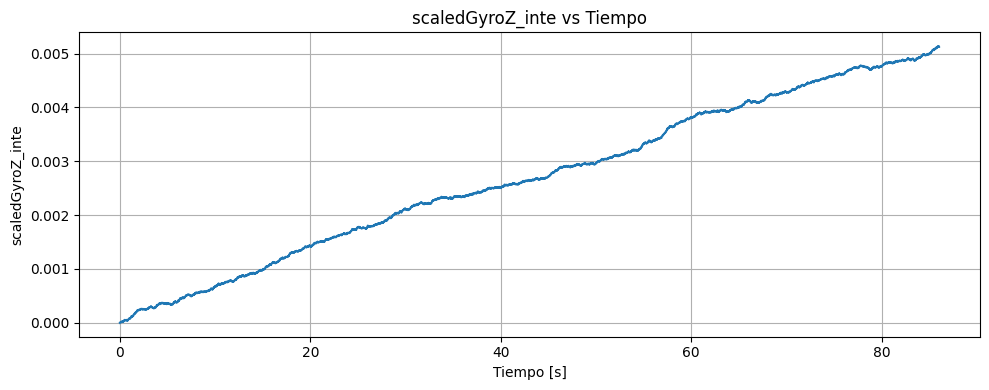

scaledGyroZ_inte  u: 0.0026892069977914918  o2: 2.126391149611911e-06  o: 0.0014582150560229143


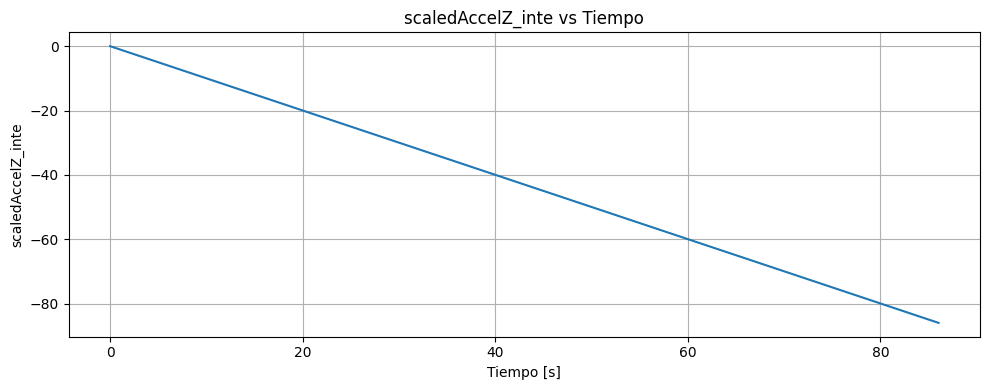

scaledAccelZ_inte  u: -42.992341040775294  o2: 615.9669666764529  o: 24.81868180779255


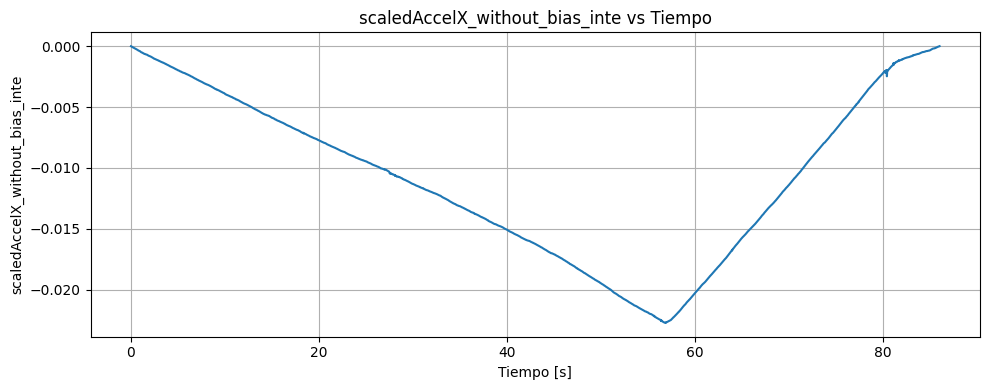

scaledAccelX_without_bias_inte  u: -0.010709126890742587  o2: 4.444456161772214e-05  o: 0.0066666754546567016


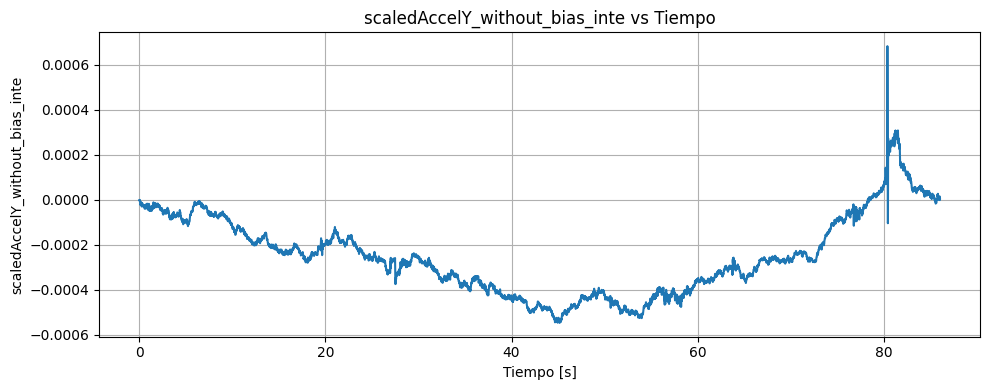

scaledAccelY_without_bias_inte  u: -0.00024957655701328586  o2: 3.0399380606722436e-08  o: 0.00017435418150053768


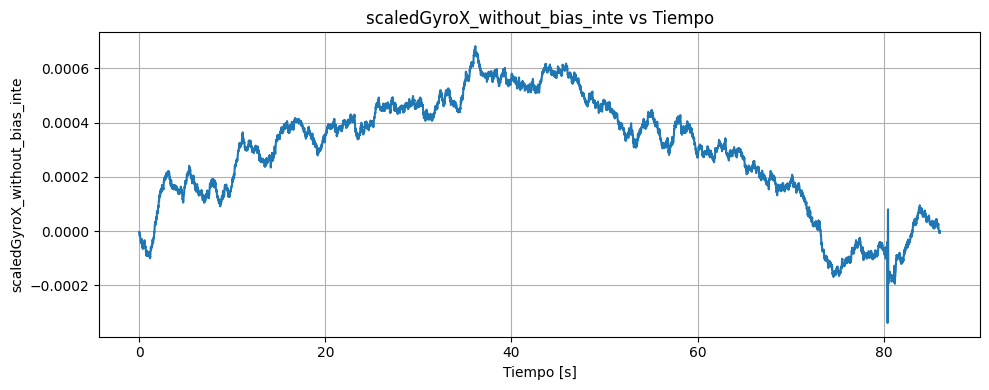

scaledGyroX_without_bias_inte  u: 0.00029094599662801663  o2: 4.405352332405643e-08  o: 0.0002098893120767621


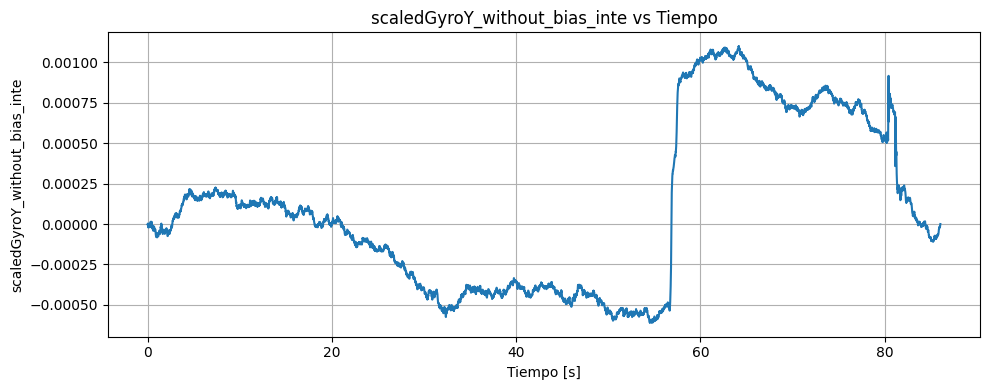

scaledGyroY_without_bias_inte  u: 9.282495913251452e-05  o2: 2.6692771802814257e-07  o: 0.0005166504795586108


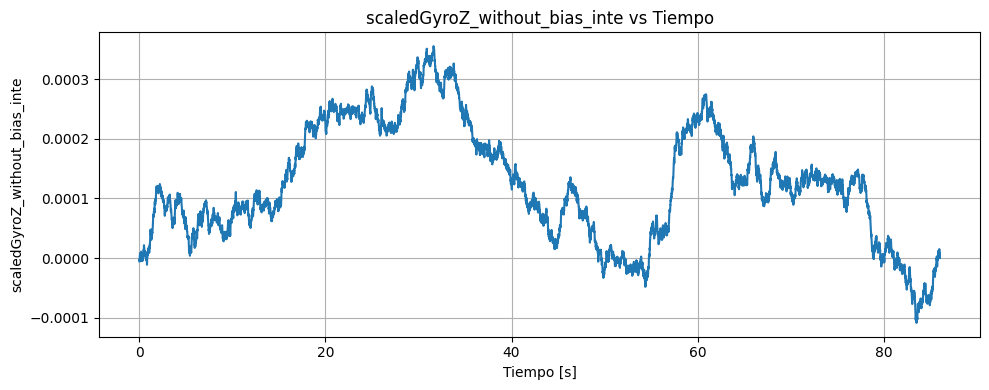

scaledGyroZ_without_bias_inte  u: 0.000125212964787292  o2: 9.42887279054562e-09  o: 9.710238303226971e-05


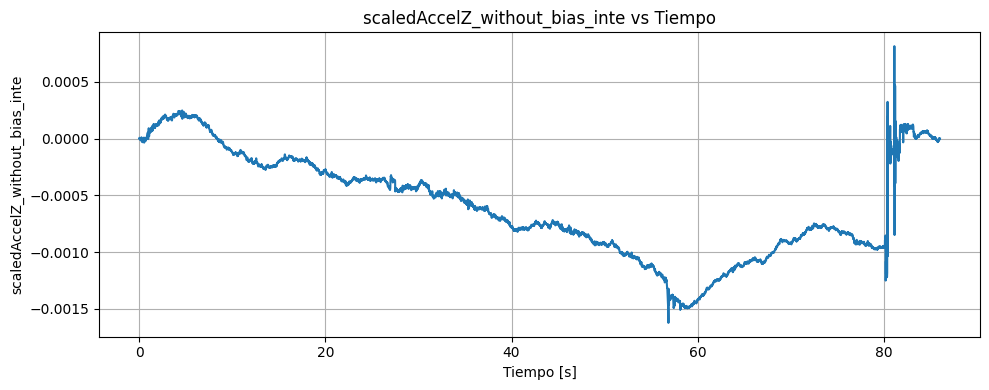

scaledAccelZ_without_bias_inte  u: -0.000589065579882039  o2: 2.0440697310769939e-07  o: 0.0004521138939556043
Index(['Time', 'scaledAccelX', 'scaledAccelY', 'scaledGyroX', 'scaledGyroY',
       'scaledGyroZ', 'scaledAccelZ', 'scaledAccelX_without_bias',
       'scaledAccelY_without_bias', 'scaledGyroX_without_bias',
       'scaledGyroY_without_bias', 'scaledGyroZ_without_bias',
       'scaledAccelZ_without_bias', 'scaledAccelX_inte', 'scaledAccelY_inte',
       'scaledGyroX_inte', 'scaledGyroY_inte', 'scaledGyroZ_inte',
       'scaledAccelZ_inte', 'scaledAccelX_without_bias_inte',
       'scaledAccelY_without_bias_inte', 'scaledGyroX_without_bias_inte',
       'scaledGyroY_without_bias_inte', 'scaledGyroZ_without_bias_inte',
       'scaledAccelZ_without_bias_inte'],
      dtype='str')


In [97]:
def plot_integ_data_vs_time(df, col_input, col_output):
    # df = df.copy()

    df[col_output] = np.cumsum(df[col_input]) * dt

    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    y = df[col_output]

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col_output)
    plt.title(f"{col_output} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for column in df.columns[1:]:
    plot_integ_data_vs_time(df=df, col_input=column, col_output=column+"_inte")
    print(column+"_inte", " u:", mean(df,column+"_inte"), " o2:", variance(df,column+"_inte")," o:", standard_deviation(df,column+"_inte"))

print(df.columns[:])
# for column in df.columns[1:]:
#     print(column, " u:", mean(df,column), " o2:", variance(df,column)," o:", standard_deviation(df,column))
    

In [ ]:
sigma_randow_walk = {}

tiempo_total = len(df) * dt
# print(T)

# print(list(biases))
# print(list(var))

def sigma_rw():
    for keys in list(std):
        # print(keys)
        sigma_randow_walk[keys] = std[keys] * np.sqrt(dt * tiempo_total)

sigma_rw()

print(std)
print(sigma_randow_walk)

def plot_angular_error_prediction(df, col):
    
    t = (df["Time"] - df["Time"].iloc[0]) / 1e9
    
    plt.plot(t, theta, label="Error angular simulado")
    plt.plot(t, sigma_theta_teorico, "--", label="+1 sigma teórico")
    plt.plot(t, -sigma_theta_teorico, "--", label="-1 sigma teórico")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Error angular [deg]")
    plt.title("Random Walk angular vs predicción teórica")
    plt.legend()
    plt.grid()
    plt.show()
    
        


{'scaledAccelX': np.float64(0.0009440056035805634), 'scaledAccelY': np.float64(0.0008293942742173464), 'scaledGyroX': np.float64(0.0005972568648660705), 'scaledGyroY': np.float64(0.0007119033430365231), 'scaledGyroZ': np.float64(0.0003323012469060419), 'scaledAccelZ': np.float64(0.0036217750130223855)}
{'scaledAccelX': np.float64(0.0008756892323983944), 'scaledAccelY': np.float64(0.0007693721653666309), 'scaledGyroX': np.float64(0.000554034217122744), 'scaledGyroY': np.float64(0.0006603838892915014), 'scaledGyroZ': np.float64(0.0003082530683339818), 'scaledAccelZ': np.float64(0.0033596721979654975)}
